# Bedrock Runtime Converse Performance And Accuracy

This notebook benchmarks Amazon Bedrock Runtime model endpoints through the Converse and ConverseStream APIs and records both latency/throughput and answer quality. Authentication is SigV4 through the standard AWS credential chain; no bearer token is required. It uses `scripts/bedrock_runtime_benchmark.py`, so notebook runs and headless CLI runs write the same CSV outputs under `results/bedrock_runtime/`.

The first sections verify credentials, choose a workload profile, optionally prepare standard accuracy datasets, and run one or more benchmark iterations. Later sections reload the generated CSVs, summarize metrics, plot distributions, and inspect wrong accuracy answers.


## Imports


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import re
import sys

PROJECT = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
SCRIPTS = PROJECT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

import bedrock_runtime_benchmark as brb


## Configuration

These cells keep credentials, workload size, and accuracy dataset selection in one place. Requests are signed with SigV4, so the only requirement is a resolvable AWS credential chain with `bedrock:InvokeModel*` permissions.


### Credentials

Bedrock Runtime authenticates every request with SigV4. boto3 resolves credentials from the standard chain: environment variables (`AWS_ACCESS_KEY_ID`/`AWS_SECRET_ACCESS_KEY`), `~/.aws/credentials`, SSO, or an instance/execution role. This cell verifies that a usable identity exists without printing any secret material.


In [2]:
import boto3

session = boto3.session.Session()
sts = session.client("sts", region_name=session.region_name or "us-west-2")
identity = sts.get_caller_identity()
print(f"SigV4 credentials resolved for account {identity['Account']}")
print(f"Caller: {identity['Arn']}")
print(f"Default session region: {session.region_name or '(none; the configuration cell sets REGION)'}")


SigV4 credentials resolved for account 976939723775
Caller: arn:aws:iam::976939723775:user/mltest
Default session region: us-west-2


### Workload Profile

`PROFILE` selects a notebook preset. The preset maps to one of the runner's base profiles and can also set request count, concurrency, input token load, output token load, and iteration count. Leave an override as `None` to use the preset value or the runner default.


In [20]:
# Model IDs or cross-region inference profile IDs served by Bedrock Runtime.
MODELS = ["openai.gpt-oss-120b-1:0"]
REGION = "us-west-2"
REGION = os.environ.get("AWS_REGION") or os.environ.get("AWS_DEFAULT_REGION") or REGION
OUT_DIR = "results/bedrock_runtime"
RUN_ID_PREFIX = ""
LIST_MODELS = True
INCLUDE_VISION = False

PROFILE_PRESETS = {
    "smoke": {
        "runner_profile": "smoke",
        "num_prompts": None,
        "max_concurrency": None,
        "input_tokens": None,
        "output_tokens": None,
        "description": "Cheap API and plotting check.",
    },
    "quick-text": {
        "runner_profile": "sglang-text",
        "num_prompts": 8,
        "max_concurrency": 2,
        "input_tokens": 256,
        "output_tokens": 128,
        "description": "Small text-only run with nontrivial prompt load.",
    },
    "latency-1k": {
        "runner_profile": "sglang-text",
        "num_prompts": 10,
        "max_concurrency": 1,
        "input_tokens": 1024,
        "output_tokens": 256,
        "description": "Single-concurrency latency probe with 1k-token synthetic inputs.",
    },
    "load-small": {
        "runner_profile": "sglang-text",
        "num_prompts": 32,
        "max_concurrency": 8,
        "input_tokens": 512,
        "output_tokens": 256,
        "description": "Small load test for request and token throughput.",
    },
    "load-medium": {
        "runner_profile": "sglang-text",
        "num_prompts": 100,
        "max_concurrency": 25,
        "input_tokens": 1024,
        "output_tokens": 512,
        "description": "Moderate load test; verify quota and cost before running.",
    },
    "load-large": {
        "runner_profile": "sglang-text",
        "num_prompts": 1000,
        "max_concurrency": 100,
        "input_tokens": 1024,
        "output_tokens": 1024,
        "description": "Full text throughput shape matching the SGLang benchmark.",
    },
    "sglang-text": {
        "runner_profile": "sglang-text",
        "num_prompts": None,
        "max_concurrency": None,
        "input_tokens": None,
        "output_tokens": None,
        "description": "Runner default text latency and throughput workloads.",
    },
    "sglang-full": {
        "runner_profile": "sglang-full",
        "num_prompts": None,
        "max_concurrency": None,
        "input_tokens": None,
        "output_tokens": None,
        "description": "Runner default text plus two-image vision workloads.",
    },
}

PROFILE = "latency-1k"
ITERATIONS = 1

# Explicit overrides. Set any of these to an integer/string to override the selected preset.
NUM_PROMPTS = None
MAX_CONCURRENCY = None
INPUT_TOKENS = None
OUTPUT_TOKENS = None
IMAGE_RESOLUTION = None

SKIP_PERFORMANCE = False
SKIP_ACCURACY = False
# Reasoning models (e.g. openai.gpt-oss-*) spend tokens on hidden reasoning before
# the final answer; small budgets truncate them mid-reasoning with empty content.
ACCURACY_MAX_TOKENS = 256
ACCURACY_CONCURRENCY = 4
TEMPERATURE = 0.0
TIMEOUT = 600.0
MAX_RETRIES = 0
SEED = 17

# Optional standard accuracy data. Disabled by default to avoid surprise downloads/API cost.
ENABLE_STANDARD_ACCURACY = False
STANDARD_ACCURACY_LIMITS = {
    "mmlu": 25,
    "gsm8k": 25,
    "arc_challenge": 25,
    "hellaswag": 25,
}
STANDARD_ACCURACY_JSONL = str(Path(OUT_DIR) / "standard_accuracy_sample.jsonl")

if PROFILE not in PROFILE_PRESETS:
    raise ValueError(f"Unknown PROFILE {PROFILE!r}. Options: {sorted(PROFILE_PRESETS)}")
if ITERATIONS < 1:
    raise ValueError("ITERATIONS must be at least 1.")

preset = PROFILE_PRESETS[PROFILE]
profile_config = {
    "profile": PROFILE,
    "runner_profile": preset["runner_profile"],
    "description": preset["description"],
    "models": MODELS,
    "region": REGION,
    "include_vision": INCLUDE_VISION,
    "iterations": ITERATIONS,
    "num_prompts": NUM_PROMPTS if NUM_PROMPTS is not None else preset.get("num_prompts"),
    "max_concurrency": MAX_CONCURRENCY if MAX_CONCURRENCY is not None else preset.get("max_concurrency"),
    "input_tokens": INPUT_TOKENS if INPUT_TOKENS is not None else preset.get("input_tokens"),
    "output_tokens": OUTPUT_TOKENS if OUTPUT_TOKENS is not None else preset.get("output_tokens"),
    "image_resolution": IMAGE_RESOLUTION,
    "accuracy_concurrency": ACCURACY_CONCURRENCY,
    "standard_accuracy_enabled": ENABLE_STANDARD_ACCURACY,
}

print("Resolved benchmark configuration:")
print(json.dumps({key: value for key, value in profile_config.items() if value is not None}, indent=2))

Resolved benchmark configuration:
{
  "profile": "latency-1k",
  "runner_profile": "sglang-text",
  "description": "Single-concurrency latency probe with 1k-token synthetic inputs.",
  "models": [
    "openai.gpt-oss-120b-1:0"
  ],
  "region": "us-east-2",
  "include_vision": false,
  "iterations": 1,
  "num_prompts": 10,
  "max_concurrency": 1,
  "input_tokens": 1024,
  "output_tokens": 256,
  "accuracy_concurrency": 4,
  "standard_accuracy_enabled": false
}


In [21]:
REGION, MODELS

('us-east-2', ['openai.gpt-oss-120b-1:0'])

## Optional Standard Accuracy Datasets

The runner always includes built-in `mini_gsm8k` and `mini_mmlu` probes. Enable this cell to sample standard datasets into the runner's JSONL format: MMLU, ARC-Challenge, and HellaSwag use multiple-choice exact match, while GSM8K uses final-number exact match. Keep limits small because every item is one API request per model.


In [15]:
ACCURACY_JSONL = ""


def choice_letter(index):
    return chr(ord("A") + int(index))


def normalize_choice_answer(answer, choices_count):
    if isinstance(answer, int):
        return choice_letter(answer)
    text = str(answer).strip().upper()
    if text.isdigit():
        value = int(text)
        if 0 <= value < choices_count:
            return choice_letter(value)
        if 1 <= value <= choices_count:
            return choice_letter(value - 1)
    return text[:1]


def limited_dataset(dataset, limit, seed):
    if limit is None:
        return dataset
    if hasattr(dataset, "shuffle"):
        dataset = dataset.shuffle(seed=seed)
    count = min(int(limit), len(dataset))
    return dataset.select(range(count))


def load_dataset_with_candidates(candidates, split):
    try:
        from datasets import load_dataset
    except ImportError as exc:
        raise RuntimeError("Install the optional dependency with `pip install datasets`.") from exc

    errors = []
    for candidate in candidates:
        dataset_name = candidate[0]
        config_name = candidate[1] if len(candidate) > 1 else None
        try:
            if config_name:
                return load_dataset(dataset_name, config_name, split=split)
            return load_dataset(dataset_name, split=split)
        except Exception as exc:
            label = f"{dataset_name}/{config_name}" if config_name else dataset_name
            errors.append(f"{label}: {exc}")
    raise RuntimeError("; ".join(errors))


def make_choice_map(values):
    return {choice_letter(index): str(value) for index, value in enumerate(values)}


def mmlu_rows(limit):
    dataset = load_dataset_with_candidates([("cais/mmlu", "all")], "test")
    rows = []
    for index, row in enumerate(limited_dataset(dataset, limit, SEED)):
        choices = row.get("choices") or [row.get(key) for key in ["A", "B", "C", "D"] if row.get(key) is not None]
        choices = [str(choice) for choice in choices]
        rows.append(
            {
                "suite": "mmlu",
                "id": str(row.get("id", f"mmlu_{index:05d}")),
                "category": str(row.get("subject") or row.get("category") or "mmlu"),
                "question": str(row.get("question") or row.get("input") or ""),
                "choices": make_choice_map(choices),
                "answer": normalize_choice_answer(row.get("answer"), len(choices)),
                "answer_type": "choice",
            }
        )
    return rows


def gsm8k_rows(limit):
    dataset = load_dataset_with_candidates([("openai/gsm8k", "main"), ("gsm8k", "main")], "test")
    rows = []
    for index, row in enumerate(limited_dataset(dataset, limit, SEED)):
        answer_text = str(row.get("answer", ""))
        match = re.search(r"####\s*(-?[\d,]+(?:\.\d+)?)", answer_text)
        answer = match.group(1).replace(",", "") if match else brb.extract_number(answer_text)
        rows.append(
            {
                "suite": "gsm8k",
                "id": str(row.get("id", f"gsm8k_{index:05d}")),
                "category": "grade_school_math",
                "question": str(row.get("question") or row.get("problem") or ""),
                "answer": answer,
                "answer_type": "numeric",
            }
        )
    return rows


def arc_challenge_rows(limit):
    dataset = load_dataset_with_candidates([("allenai/ai2_arc", "ARC-Challenge"), ("ai2_arc", "ARC-Challenge")], "test")
    rows = []
    for index, row in enumerate(limited_dataset(dataset, limit, SEED)):
        raw_choices = row.get("choices") or {}
        texts = raw_choices.get("text", []) if isinstance(raw_choices, dict) else []
        labels = raw_choices.get("label", []) if isinstance(raw_choices, dict) else []
        choices = {}
        label_to_choice = {}
        for pos, text in enumerate(texts):
            label = str(labels[pos]).strip().upper() if pos < len(labels) else choice_letter(pos)
            canonical = label if len(label) == 1 and label.isalpha() else choice_letter(pos)
            choices[canonical] = str(text)
            label_to_choice[label] = canonical
        answer_key = str(row.get("answerKey") or row.get("answer") or "").strip().upper()
        rows.append(
            {
                "suite": "arc_challenge",
                "id": str(row.get("id", f"arc_challenge_{index:05d}")),
                "category": "science_reasoning",
                "question": str(row.get("question") or ""),
                "choices": choices,
                "answer": label_to_choice.get(answer_key, answer_key),
                "answer_type": "choice",
            }
        )
    return rows


def hellaswag_rows(limit):
    dataset = load_dataset_with_candidates([("Rowan/hellaswag",)], "validation")
    rows = []
    for index, row in enumerate(limited_dataset(dataset, limit, SEED)):
        endings = [str(value) for value in row.get("endings", [])]
        context = " ".join(str(row.get(key, "")).strip() for key in ["ctx_a", "ctx_b"]).strip()
        if not context:
            context = str(row.get("ctx", ""))
        rows.append(
            {
                "suite": "hellaswag",
                "id": str(row.get("ind", row.get("id", f"hellaswag_{index:05d}"))),
                "category": str(row.get("activity_label") or "commonsense_completion"),
                "question": f"{context}\nWhich ending is most plausible?",
                "choices": make_choice_map(endings),
                "answer": normalize_choice_answer(row.get("label"), len(endings)),
                "answer_type": "choice",
            }
        )
    return rows


if ENABLE_STANDARD_ACCURACY:
    builders = {
        "mmlu": mmlu_rows,
        "gsm8k": gsm8k_rows,
        "arc_challenge": arc_challenge_rows,
        "hellaswag": hellaswag_rows,
    }
    standard_rows = []
    for suite, limit in STANDARD_ACCURACY_LIMITS.items():
        if not limit:
            print(f"{suite}: skipped by limit={limit}")
            continue
        try:
            rows = builders[suite](limit)
        except Exception as exc:
            print(f"{suite}: skipped ({exc})")
            continue
        print(f"{suite}: prepared {len(rows)} items")
        standard_rows.extend(rows)

    if not standard_rows:
        raise RuntimeError("No standard accuracy rows were created. Check dataset availability and limits.")

    accuracy_path = Path(STANDARD_ACCURACY_JSONL)
    accuracy_path.parent.mkdir(parents=True, exist_ok=True)
    with accuracy_path.open("w", encoding="utf-8") as handle:
        for row in standard_rows:
            handle.write(json.dumps(row, ensure_ascii=False) + "\n")
    ACCURACY_JSONL = str(accuracy_path)
    print(f"Wrote {len(standard_rows)} standard accuracy items to {ACCURACY_JSONL}")
else:
    print("Standard accuracy disabled; the runner will use built-in mini_gsm8k and mini_mmlu probes.")


Standard accuracy disabled; the runner will use built-in mini_gsm8k and mini_mmlu probes.


## Run Benchmark

This cell builds the same argument list used by the CLI, applies the selected preset and overrides, and runs `ITERATIONS` independent benchmark passes. Each iteration writes separate CSV files and a manifest under `OUT_DIR`.


In [16]:
def append_option(argv, flag, value):
    if value is not None and value != "":
        argv.extend([flag, str(value)])


def build_benchmark_argv(run_id):
    argv = [
        "--profile",
        profile_config["runner_profile"],
        "--region",
        REGION,
        "--out-dir",
        OUT_DIR,
        "--models",
        *MODELS,
    ]
    append_option(argv, "--run-id", run_id)
    append_option(argv, "--num-prompts", profile_config.get("num_prompts"))
    append_option(argv, "--max-concurrency", profile_config.get("max_concurrency"))
    append_option(argv, "--input-tokens", profile_config.get("input_tokens"))
    append_option(argv, "--output-tokens", profile_config.get("output_tokens"))
    append_option(argv, "--image-resolution", profile_config.get("image_resolution"))
    append_option(argv, "--accuracy-jsonl", ACCURACY_JSONL)
    append_option(argv, "--accuracy-max-tokens", ACCURACY_MAX_TOKENS)
    append_option(argv, "--accuracy-concurrency", ACCURACY_CONCURRENCY)
    append_option(argv, "--temperature", TEMPERATURE)
    append_option(argv, "--timeout", TIMEOUT)
    append_option(argv, "--max-retries", MAX_RETRIES)
    append_option(argv, "--seed", SEED)
    if INCLUDE_VISION:
        argv.append("--include-vision")
    if SKIP_PERFORMANCE:
        argv.append("--skip-performance")
    if SKIP_ACCURACY:
        argv.append("--skip-accuracy")
    if LIST_MODELS:
        argv.append("--list-models")
    return argv


base_run_id = RUN_ID_PREFIX.strip() or datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + f"_{PROFILE.replace('-', '_')}"
manifests = []
for iteration in range(ITERATIONS):
    run_id = base_run_id if ITERATIONS == 1 else f"{base_run_id}_iter{iteration + 1:02d}"
    print(f"\n=== Iteration {iteration + 1}/{ITERATIONS}: {run_id} ===")
    args = brb.parse_args(build_benchmark_argv(run_id))
    manifests.append(brb.run_benchmark(args))

manifest = manifests[-1]
manifest



=== Iteration 1/1: 20260714_180004_latency_1k ===

Available Bedrock models and inference profiles in us-west-2:
amazon.nova-2-lite-v1:0
amazon.nova-2-sonic-v1:0
amazon.nova-lite-v1:0
amazon.nova-micro-v1:0
amazon.nova-premier-v1:0
amazon.nova-premier-v1:0:1000k
amazon.nova-premier-v1:0:20k
amazon.nova-premier-v1:0:8k
amazon.nova-premier-v1:0:mm
amazon.nova-pro-v1:0
amazon.rerank-v1:0
amazon.titan-embed-g1-text-02
amazon.titan-embed-image-v1
amazon.titan-embed-image-v1:0
amazon.titan-embed-text-v1
amazon.titan-embed-text-v1:2:8k
amazon.titan-embed-text-v2:0
anthropic.claude-3-haiku-20240307-v1:0
anthropic.claude-3-haiku-20240307-v1:0:200k
anthropic.claude-3-haiku-20240307-v1:0:48k
anthropic.claude-3-sonnet-20240229-v1:0
anthropic.claude-3-sonnet-20240229-v1:0:200k
anthropic.claude-3-sonnet-20240229-v1:0:28k
anthropic.claude-fable-5
anthropic.claude-haiku-4-5-20251001-v1:0
anthropic.claude-opus-4-1-20250805-v1:0
anthropic.claude-opus-4-5-20251101-v1:0
anthropic.claude-opus-4-6-v1
anthr

{'run_id': '20260714_180004_latency_1k',
 'created_utc': '2026-07-14T18:00:59Z',
 'api': 'bedrock-runtime converse',
 'auth': 'sigv4',
 'region': 'us-west-2',
 'models': ['openai.gpt-oss-120b-1:0'],
 'profile': 'sglang-text',
 'include_vision': False,
 'workloads': [{'name': 'text_latency',
   'modality': 'text',
   'num_prompts': 10,
   'max_concurrency': 1,
   'random_input_len': 1024,
   'max_output_tokens': 256,
   'image_count': 0,
   'image_resolution': '720p'},
  {'name': 'text_throughput',
   'modality': 'text',
   'num_prompts': 10,
   'max_concurrency': 1,
   'random_input_len': 1024,
   'max_output_tokens': 256,
   'image_count': 0,
   'image_resolution': '720p'}],
 'skip_performance': False,
 'skip_accuracy': False,
 'paths': {'performance_csv': '/opt/dlami/nvme/codes/inference/notebooks/results/bedrock_runtime/bedrock_runtime_performance_20260714_180004_latency_1k.csv',
  'performance_summary_csv': '/opt/dlami/nvme/codes/inference/notebooks/results/bedrock_runtime/bedrock_

     1/10: TTFT=   793.3 ms  lat=   3776.9 ms  out=  256  rate=  85.80 tok/s


     2/10: TTFT=   657.2 ms  lat=   2299.2 ms  out=  256  rate= 155.91 tok/s


     3/10: TTFT=   647.1 ms  lat=    982.3 ms  out=  256  rate= 763.85 tok/s


...

    16/18: mini_mmlu:mmlu_009 ok pred=B expected=B


    17/18: mini_mmlu:mmlu_008 ok pred=B expected=B


    18/18: mini_mmlu:mmlu_010 ok pred=C expected=C



Performance summary
model                    workload         successful_requests  errors  request_rps  aggregate_output_tps  ttft_p50_ms  latency_p50_ms  latency_p90_ms
-----------------------  ---------------  -------------------  ------  -----------  --------------------  -----------  --------------  --------------
openai.gpt-oss-120b-1:0  text_latency     10                   0       0.496        127.098               677.376      1998.741        2476.919      
openai.gpt-oss-120b-1:0  text_throughput  10                   0       0.404        103.33                723.332      1979.808        4325.926      

Accuracy summary
model                    suite       items  correct  accuracy  latency_mean_ms
-----------------------  ----------  -----  -------  --------  ---------------
openai.gpt-oss-120b-1:0  mini_gsm8k  8      8        1.0       811.159        
openai.gpt-oss-120b-1:0  mini_mmlu   10     10       1.0       727.133        

Wrote outputs:
  performance_csv: /opt/dlami

{'run_id': '20260714_171850_latency_1k',
 'created_utc': '2026-07-14T17:19:40Z',
 'api': 'bedrock-runtime converse',
 'auth': 'sigv4',
 'region': 'us-east-1',
 'models': ['openai.gpt-oss-120b-1:0'],
 'profile': 'sglang-text',
 'include_vision': False,
 'workloads': [{'name': 'text_latency',
   'modality': 'text',
   'num_prompts': 10,
   'max_concurrency': 1,
   'random_input_len': 1024,
   'max_output_tokens': 256,
   'image_count': 0,
   'image_resolution': '720p'},
  {'name': 'text_throughput',
   'modality': 'text',
   'num_prompts': 10,
   'max_concurrency': 1,
   'random_input_len': 1024,
   'max_output_tokens': 256,
   'image_count': 0,
   'image_resolution': '720p'}],
 'skip_performance': False,
 'skip_accuracy': False,
 'paths': {'performance_csv': '/opt/dlami/nvme/codes/inference/notebooks/results/bedrock_runtime/bedrock_runtime_performance_20260714_171850_latency_1k.csv',
  'performance_summary_csv': '/opt/dlami/nvme/codes/inference/notebooks/results/bedrock_runtime/bedrock_

## Load Results


In [17]:
import pandas as pd


def read_csv_if_present(path):
    return pd.read_csv(path) if path.exists() and path.stat().st_size else pd.DataFrame()


def truthy(series):
    return series.astype(str).str.lower().isin(["true", "1", "yes"])


if "manifests" in globals() and manifests:
    loaded_manifests = manifests
else:
    latest_manifest = Path(OUT_DIR) / "latest_bedrock_runtime_manifest.json"
    with latest_manifest.open("r", encoding="utf-8") as handle:
        loaded_manifests = [json.load(handle)]

perf_frames = []
perf_summary_frames = []
accuracy_frames = []
acc_summary_frames = []
for item in loaded_manifests:
    run_id = item["run_id"]
    item_paths = {key: Path(value) for key, value in item["paths"].items()}
    for frames, key in [
        (perf_frames, "performance_csv"),
        (perf_summary_frames, "performance_summary_csv"),
        (accuracy_frames, "accuracy_csv"),
        (acc_summary_frames, "accuracy_summary_csv"),
    ]:
        frame = read_csv_if_present(item_paths[key])
        if not frame.empty:
            frame.insert(0, "run_id", run_id)
            frames.append(frame)

perf = pd.concat(perf_frames, ignore_index=True) if perf_frames else pd.DataFrame()
perf_summary = pd.concat(perf_summary_frames, ignore_index=True) if perf_summary_frames else pd.DataFrame()
accuracy = pd.concat(accuracy_frames, ignore_index=True) if accuracy_frames else pd.DataFrame()
acc_summary = pd.concat(acc_summary_frames, ignore_index=True) if acc_summary_frames else pd.DataFrame()

manifest = loaded_manifests[-1]
paths = {key: Path(value) for key, value in manifest["paths"].items()}

print("Run IDs:", ", ".join(item["run_id"] for item in loaded_manifests))
print("Profile:", manifest["profile"])
print("Region:", manifest["region"])
print("Performance rows:", len(perf))
print("Accuracy rows:", len(accuracy))


Run IDs: 20260714_180004_latency_1k
Profile: sglang-text
Region: us-west-2
Performance rows: 20
Accuracy rows: 18


## Numeric Summaries


In [18]:
perf_cols = [
    "run_id", "model", "workload", "successful_requests", "errors", "request_rps",
    "aggregate_output_tps", "ttft_p50_ms", "latency_p50_ms", "latency_p90_ms",
    "per_request_output_tps_mean", "prompt_tokens_mean", "completion_tokens_mean",
]
if not perf_summary.empty:
    display(perf_summary[[col for col in perf_cols if col in perf_summary.columns]])
else:
    print("No performance summary rows.")

acc_cols = ["run_id", "model", "suite", "category", "items", "correct", "accuracy", "latency_mean_ms"]
if not acc_summary.empty:
    display(acc_summary[[col for col in acc_cols if col in acc_summary.columns]])
else:
    print("No accuracy summary rows.")


,run_id,model,workload,successful_requests,errors,request_rps,aggregate_output_tps,ttft_p50_ms,latency_p50_ms,latency_p90_ms,per_request_output_tps_mean,prompt_tokens_mean,completion_tokens_mean
0,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,text_latency,10,0,0.376,96.176,613.931,2555.609,3530.069,145.801,1186.3,256.0
1,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,text_throughput,10,0,0.416,106.502,623.447,2263.213,3439.061,170.655,1186.3,256.0


,run_id,model,suite,category,items,correct,accuracy,latency_mean_ms
0,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_gsm8k,NaN,8,8,1.0,701.740
1,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_gsm8k,arithmetic,7,7,1.0,712.515
2,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_gsm8k,geometry,1,1,1.0,626.319
3,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_mmlu,NaN,10,10,1.0,719.142
4,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_mmlu,anatomy,1,1,1.0,609.270
5,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_mmlu,astronomy,1,1,1.0,556.521
6,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_mmlu,biology,1,1,1.0,554.839
7,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_mmlu,chemistry,1,1,1.0,716.234
8,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_mmlu,computer_science,2,2,1.0,670.649
9,20260714_180004_latency_1k,openai.gpt-oss-120b-1:0,mini_mmlu,geography,1,1,1.0,982.080


## Performance Charts


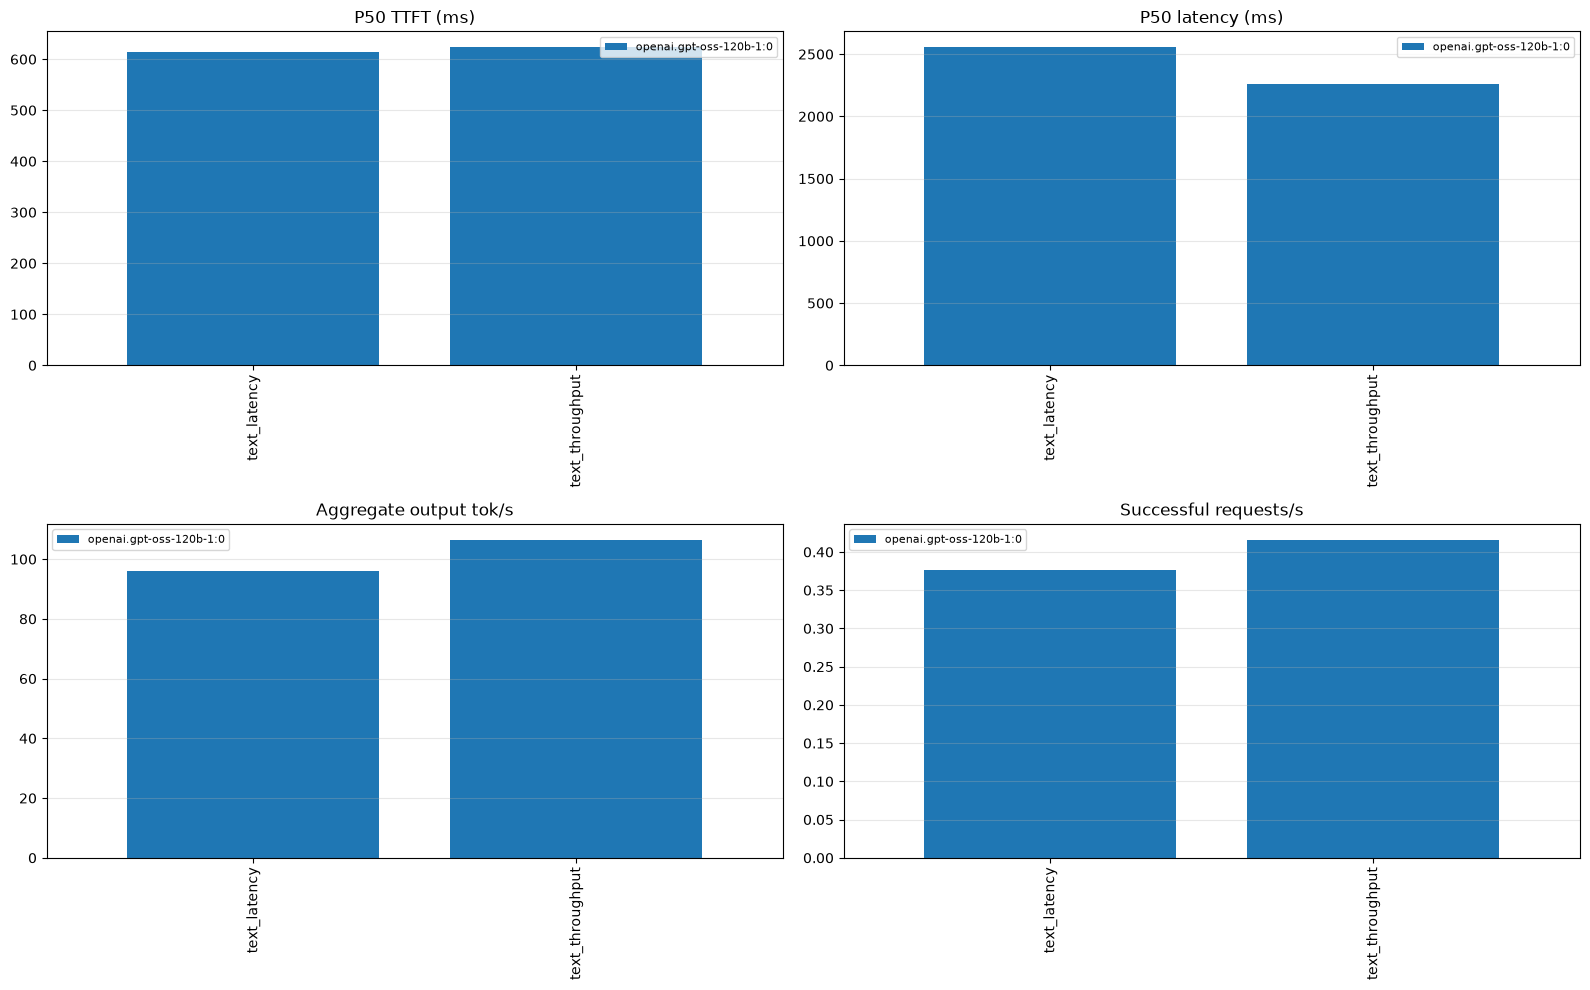

In [19]:
import matplotlib.pyplot as plt

if perf_summary.empty:
    print("No performance summary rows to plot.")
else:
    metrics = [
        ("ttft_p50_ms", "P50 TTFT (ms)"),
        ("latency_p50_ms", "P50 latency (ms)"),
        ("aggregate_output_tps", "Aggregate output tok/s"),
        ("request_rps", "Successful requests/s"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    for ax, (metric, title) in zip(axes.ravel(), metrics):
        pivot = perf_summary.pivot_table(index="workload", columns="model", values=metric, aggfunc="mean")
        pivot.plot(kind="bar", ax=ax, width=0.78)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## Request-Level Latency


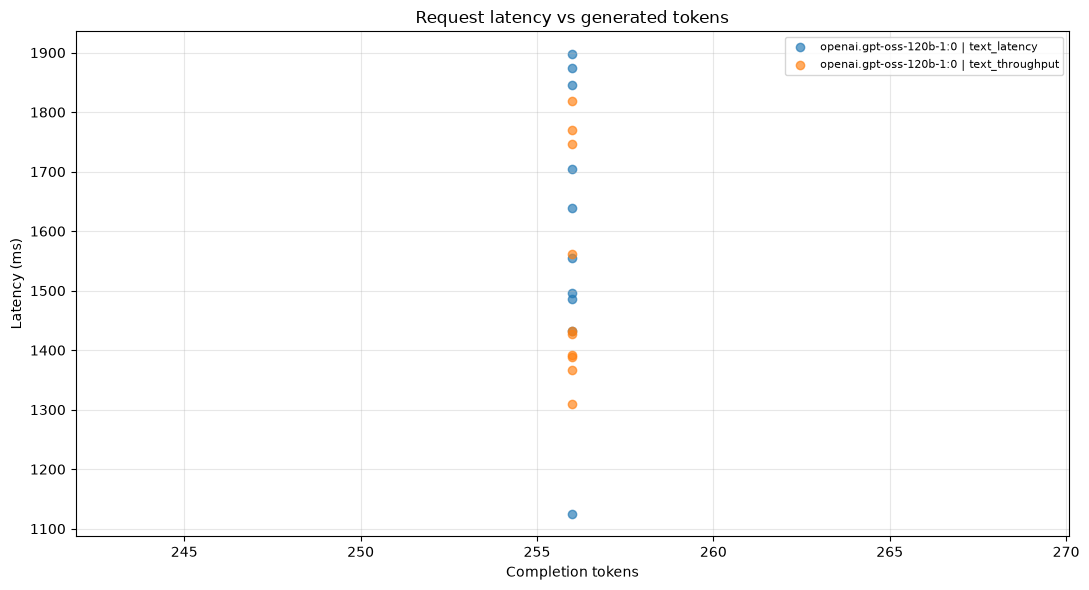

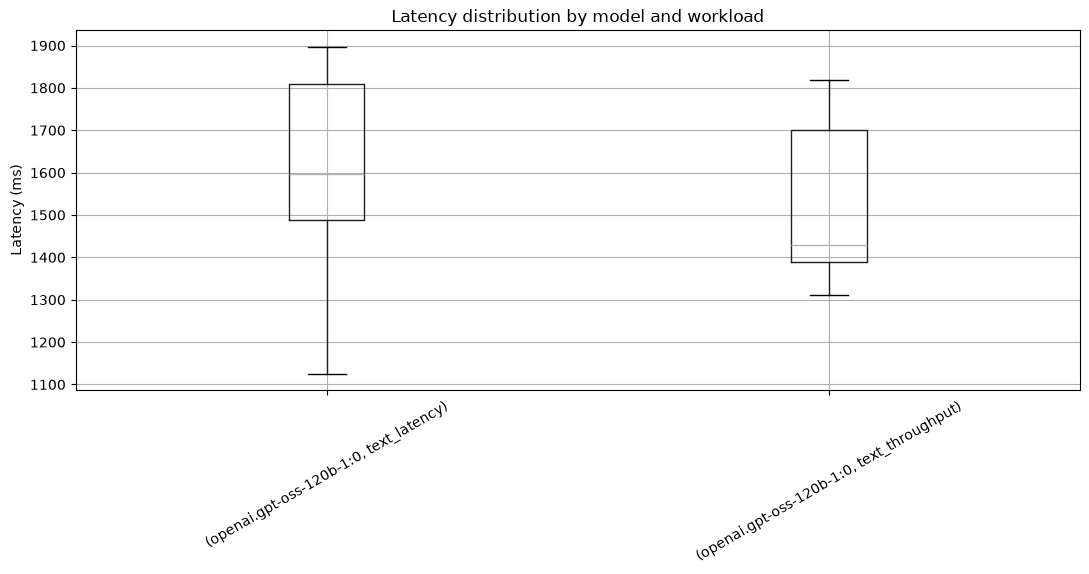

In [10]:
if perf.empty:
    print("No performance request rows to plot.")
else:
    ok_perf = perf[truthy(perf["ok"])].copy()
    if ok_perf.empty:
        print("No successful performance requests.")
    else:
        fig, ax = plt.subplots(figsize=(11, 6))
        for (model, workload), group in ok_perf.groupby(["model", "workload"]):
            ax.scatter(
                group["completion_tokens"],
                group["latency_ms"],
                alpha=0.65,
                s=36,
                label=f"{model} | {workload}",
            )
        ax.set_xlabel("Completion tokens")
        ax.set_ylabel("Latency (ms)")
        ax.set_title("Request latency vs generated tokens")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(11, 6))
        ok_perf.boxplot(column="latency_ms", by=["model", "workload"], ax=ax, rot=30)
        ax.set_title("Latency distribution by model and workload")
        ax.set_xlabel("")
        ax.set_ylabel("Latency (ms)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()


## Accuracy Charts


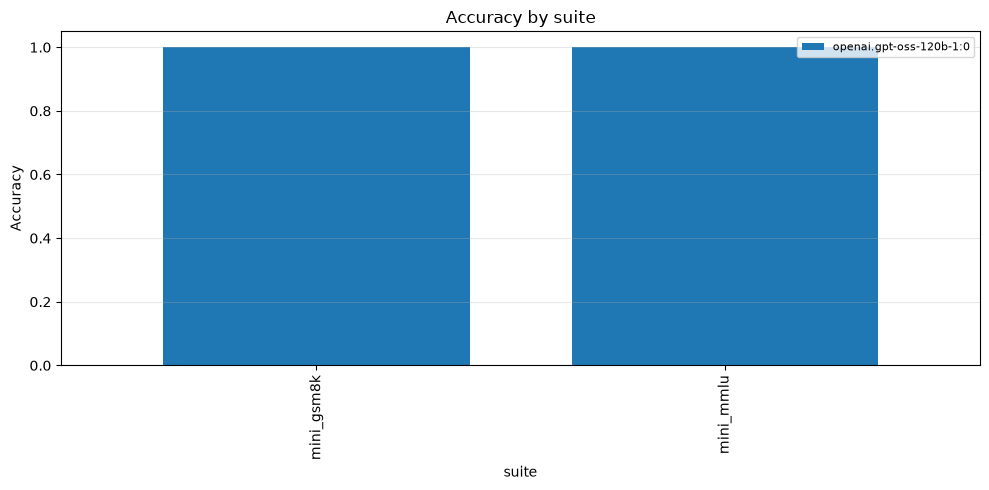

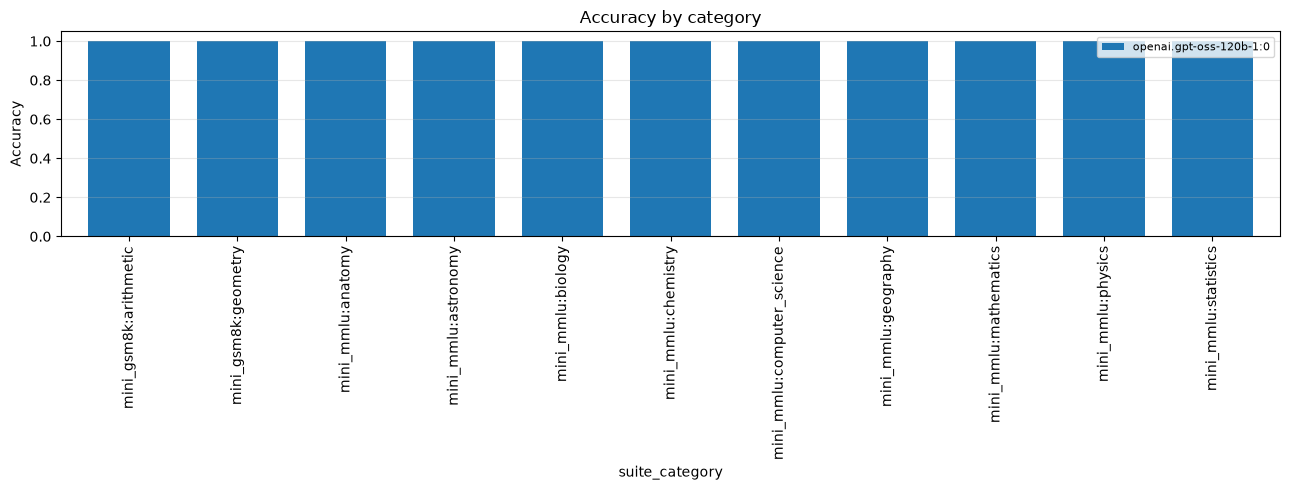

In [11]:
if acc_summary.empty:
    print("No accuracy summary rows to plot.")
else:
    suite_rows = acc_summary.copy()
    if "category" in suite_rows.columns:
        suite_rows = suite_rows[suite_rows["category"].isna()]
    if not suite_rows.empty:
        pivot = suite_rows.pivot_table(index="suite", columns="model", values="accuracy", aggfunc="mean")
        ax = pivot.plot(kind="bar", figsize=(10, 5), width=0.75)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Accuracy")
        ax.set_title("Accuracy by suite")
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

    if "category" in acc_summary.columns:
        category_rows = acc_summary[acc_summary["category"].notna()].copy()
        if not category_rows.empty:
            category_rows["suite_category"] = category_rows["suite"].astype(str) + ":" + category_rows["category"].astype(str)
            pivot = category_rows.pivot_table(index="suite_category", columns="model", values="accuracy", aggfunc="mean")
            ax = pivot.plot(kind="bar", figsize=(13, 5), width=0.75)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel("Accuracy")
            ax.set_title("Accuracy by category")
            ax.grid(True, axis="y", alpha=0.3)
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()


## Accuracy Error Inspection


In [12]:
if accuracy.empty:
    print("No accuracy rows.")
else:
    wrong = accuracy[truthy(accuracy["ok"]) & ~truthy(accuracy["correct"])]
    display(wrong[["model", "suite", "item_id", "category", "expected", "prediction", "output_text"]])


,model,suite,item_id,category,expected,prediction,output_text


## Headless CLI Equivalent

The notebook calls the same runner as the command line. A few equivalent examples:

```bash
python scripts/bedrock_runtime_benchmark.py --profile smoke --list-models
python scripts/bedrock_runtime_benchmark.py --profile sglang-text --num-prompts 32 --max-concurrency 8 --input-tokens 512 --output-tokens 256
python scripts/bedrock_runtime_benchmark.py --profile sglang-full --accuracy-jsonl results/bedrock_runtime/standard_accuracy_sample.jsonl
```
